# Part 5 Task

## Graph 1

For Graph 1, I will collect daily Wikipedia pageviews for each selected drama from June 1, 2022, to June 1, 2024. I will calculate the total pageviews for each drama, sort the totals in descending order, and create a horizontal bar chart.

First, I extract the top 20 shows in the csv file by popularity. Then, I remove Bloodhounds.

In [24]:
import pandas as pd

dramas = pd.read_csv("kdramas_2023.csv")

top20 = dramas.sort_values("Popularity").head(20)

top20 = top20[top20["Title_English"] != "Bloodhounds (2023)"]

I look up some shows on wikipedia, and they do not include the year. So, I remove the year.

In [25]:

titles = []

for title in top20["Title_English"]:
    title_noyear = title.replace(" (2023)", "")
    titles.append(title_noyear)

I want to see if all pages exist in wikipedia.

In [26]:
from mwclient import Site

site = Site("en.wikipedia.org")

for title in titles:
    page = site.pages[title]
    print(title, "→", page.exists)

Twinkling Watermelon → True
My Demon → True
King the Land → True
The Glory Part 2 → False
Moving → True
Death's Game → True
Welcome to Samdal-ri → True
See You in My 19th Life → True
Destined with You → True
The Good Bad Mother → True
My Lovely Liar → True
Crash Course in Romance → True
Love to Hate You → True
Perfect Marriage Revenge → True
A Time Called You → True
Doona! → True
Celebrity → True
Daily Dose of Sunshine → True
Gyeongseong Creature → True


It seems like only The Glory Part 2 is false. I will manually search up its wikipedia name and replace it. Furthermore, although some shows say true, it might not refer to the show. For exmaple, Moving might refer to the verb, and celebrity might refer to the noun. So, I will also verify manually

In [30]:
edit = {
    "The Glory Part 2": "The Glory (TV series)",
    "Moving": "Moving (South Korean TV series)",
    "Celebrity": "Celebrity (South Korean TV series)",
    "Love to Hate You": "Love to Hate You (TV series)"}

wiki_titles = []

for title in titles:
    if title in edit:
        title = edit[title]
    wiki_titles.append(title)

for title in wiki_titles:
    page = site.pages[title]
    print(title, "→", page.exists)

Twinkling Watermelon → True
My Demon → True
King the Land → True
The Glory (TV series) → True
Moving (South Korean TV series) → True
Death's Game → True
Welcome to Samdal-ri → True
See You in My 19th Life → True
Destined with You → True
The Good Bad Mother → True
My Lovely Liar → True
Crash Course in Romance → True
Love to Hate You (TV series) → True
Perfect Marriage Revenge → True
A Time Called You → True
Doona! → True
Celebrity (South Korean TV series) → True
Daily Dose of Sunshine → True
Gyeongseong Creature → True


In [ ]:
from mwviews.api import PageviewsClient
p = PageviewsClient(user_agent="Kdrama Lover (wendy_wellesley@gmail.com)")
data = p.article_views('en.wikipedia', wiki_titles, 
                       start='20220601', end='20240601')

#list(data.items())[:5]

[(datetime.datetime(2022, 6, 1, 0, 0),
  {'Twinkling_Watermelon': None,
   'My_Demon': None,
   'King_the_Land': None,
   'The_Glory_(TV_series)': None,
   'Moving_(South_Korean_TV_series)': 199,
   "Death's_Game": None,
   'Welcome_to_Samdal-ri': None,
   'See_You_in_My_19th_Life': None,
   'Destined_with_You': None,
   'The_Good_Bad_Mother': None,
   'My_Lovely_Liar': None,
   'Crash_Course_in_Romance': None,
   'Love_to_Hate_You_(TV_series)': None,
   'Perfect_Marriage_Revenge': None,
   'A_Time_Called_You': 134,
   'Doona!': None,
   'Celebrity_(South_Korean_TV_series)': None,
   'Daily_Dose_of_Sunshine': None,
   'Gyeongseong_Creature': None}),
 (datetime.datetime(2022, 6, 2, 0, 0),
  {'Twinkling_Watermelon': None,
   'My_Demon': None,
   'King_the_Land': None,
   'The_Glory_(TV_series)': None,
   'Moving_(South_Korean_TV_series)': 176,
   "Death's_Game": None,
   'Welcome_to_Samdal-ri': None,
   'See_You_in_My_19th_Life': None,
   'Destined_with_You': None,
   'The_Good_Bad_Mothe

I get the total view counts for each show from 2022.06.01 to 2024.06.01

In [63]:
rows = []

for date, shows in data.items():
    for title, count in shows.items():
        rows.append({
            "date": date,
            "show": title,
            "pageviews": count
        })

views = pd.DataFrame(rows)
views.head()

totals = views.groupby("show")["pageviews"].sum()
totals = totals.sort_values(ascending=True)
totals

show
Destined_with_You                        1156.0
Daily_Dose_of_Sunshine                 559765.0
Love_to_Hate_You_(TV_series)           822729.0
Doona!                                1033094.0
My_Lovely_Liar                        1169482.0
The_Good_Bad_Mother                   1172570.0
See_You_in_My_19th_Life               1247697.0
Perfect_Marriage_Revenge              1266164.0
A_Time_Called_You                     1349860.0
Celebrity_(South_Korean_TV_series)    1441608.0
Welcome_to_Samdal-ri                  1460872.0
Crash_Course_in_Romance               1488160.0
Death's_Game                          1963050.0
Twinkling_Watermelon                  2061432.0
Gyeongseong_Creature                  2081110.0
King_the_Land                         2697595.0
My_Demon                              2822146.0
Moving_(South_Korean_TV_series)       2891114.0
The_Glory_(TV_series)                 5437126.0
Name: pageviews, dtype: float64

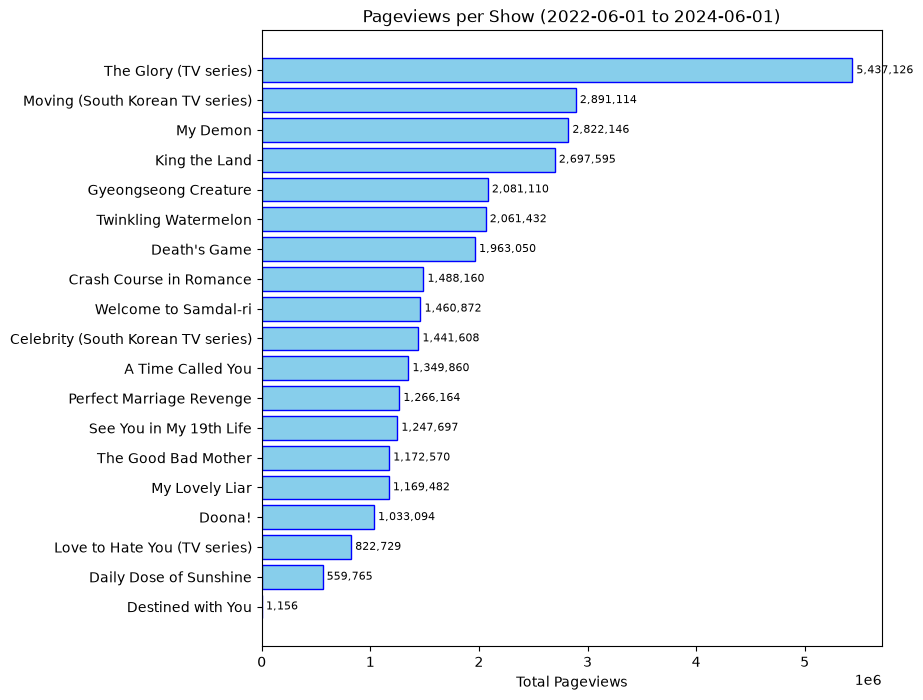

In [80]:
import matplotlib.pyplot as plt

names = []
labels = []
for title, viewcount in totals.items():
    names.append(title.replace("_", " "))
    labels.append(f"{viewcount:,.0f}")

plt.figure(figsize=(8, 8))
barplot = plt.barh(names, totals, color="skyblue", edgecolor = "blue")
plt.title("Pageviews per Show (2022-06-01 to 2024-06-01)")
plt.xlabel("Total Pageviews")

plt.bar_label(barplot, labels = labels, padding=3, fontsize=8)
plt.show()

